<a href="https://colab.research.google.com/github/vrajkmrpatel/AI_ML_DATASCIENCE/blob/main/DeepLearning/NST/Neural_style_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
device

device(type='cuda')

In [ ]:
def get_image(path, img_transform, size = (300,300)):
  image = Image.open(path)
  image = image.resize(size, Image.LANCZOS)
  image = img_transform(image).unsqueeze(0)
  return image.to(device)

def get_gram(m):
  """
    m is of shape (1, C, H, W) """
  _, c, h, w = m.size()
  m = m.view(c, h*w)
  m = torch.mm(m, m.t())
  return m

def denormalize_img(inp):
  inp = inp.numpy().transpose((1, 2, 0))
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = inp * std + mean
  inp = inp.clip(inp, 0, 1)
  return inp


In [ ]:
class FeatureEXtractor(nn.Module):
  def __init__(self):
    super(FeatureEXtractor, self).__init__()
    self.selected_layers = [3, 8, 15, 22]
    self.vgg = models.vgg16(pretrained = True).features

  def forward(self, x):
    layer_feats = []
    for layer_num, layer in self.vgg._modules.items():
      x = layer(x)
      if int(layer_num) in self.selected_layers:
        layer_feats.append(x)
    return layer_feats

In [ ]:
# Redefine get_image locally to ensure images are in RGB before processing
def get_image(path, img_transform, size = (300,300)):
  image = Image.open(path).convert("RGB") # Convert image to RGB
  image = image.resize(size, Image.LANCZOS)
  image = img_transform(image).unsqueeze(0)
  return image.to(device)

img_transform = transforms.Compose([transforms.ToTensor(),
                                    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))])

content_img = get_image('background.avif', img_transform)
style_img = get_image('chess2.jpg', img_transform)
generated_img = content_img.clone()    # or nn.Parameter(torch.FloatTensor(content_img.size()))
generated_img.requires_grad = True

optimizer = torch.optim.Adam([generated_img], lr=0.003, betas=[0.5, 0.999])
encoder = FeatureEXtractor().to(device) # Corrected class name from FeatureExtractor to FeatureEXtractor

for p in encoder.parameters():
    p.requires_grad = False

In [ ]:
content_weight = 1
style_weight = 1000

for epoch in range(500):

    content_features = encoder(content_img)
    style_features = encoder(style_img)
    generated_features = encoder(generated_img)

    content_loss = torch.mean((content_features[-1] - generated_features[-1])**2)

    style_loss = 0
    for gf, sf in zip(generated_features, style_features):
        _, c, h, w = gf.size()
        gram_gf = get_gram(gf)
        gram_sf = get_gram(sf)
        style_loss += torch.mean((gram_gf - gram_sf)**2)  / (c * h * w)

    loss = content_weight * content_loss + style_weight * style_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print ('Epoch [{}]\tContent Loss: {:.4f}\tStyle Loss: {:.4f}'.format(epoch, content_loss.item(), style_loss.item()))

Epoch [0]	Content Loss: 12.6227	Style Loss: 14777.9326
Epoch [10]	Content Loss: 12.6334	Style Loss: 14727.5986
Epoch [20]	Content Loss: 12.6391	Style Loss: 14702.0527
Epoch [30]	Content Loss: 12.6451	Style Loss: 14677.4971
Epoch [40]	Content Loss: 12.6514	Style Loss: 14653.0020
Epoch [50]	Content Loss: 12.6580	Style Loss: 14628.4014
Epoch [60]	Content Loss: 12.6645	Style Loss: 14603.6348
Epoch [70]	Content Loss: 12.6712	Style Loss: 14578.7168
Epoch [80]	Content Loss: 12.6780	Style Loss: 14553.6328
Epoch [90]	Content Loss: 12.6846	Style Loss: 14528.4131
Epoch [100]	Content Loss: 12.6914	Style Loss: 14503.0449
Epoch [110]	Content Loss: 12.6982	Style Loss: 14477.5225
Epoch [120]	Content Loss: 12.7050	Style Loss: 14451.8613
Epoch [130]	Content Loss: 12.7121	Style Loss: 14426.0801
Epoch [140]	Content Loss: 12.7193	Style Loss: 14400.1553
Epoch [150]	Content Loss: 12.7266	Style Loss: 14374.0918
Epoch [160]	Content Loss: 12.7339	Style Loss: 14347.9102
Epoch [170]	Content Loss: 12.7414	Style Lo

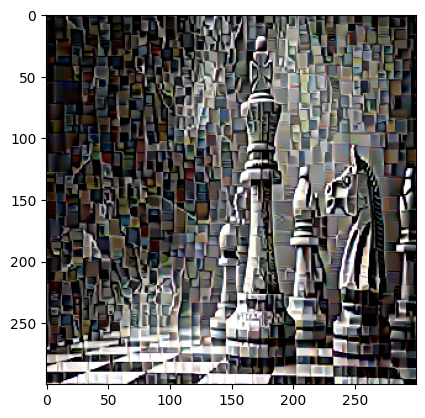

In [ ]:
def denormalize_img(inp):
  inp = inp.numpy().transpose((1, 2, 0))
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = inp * std + mean
  inp = inp.clip(0, 1) # Corrected: 'inp' should not be passed as a min/max argument
  return inp

inp = generated_img.detach().cpu().squeeze()
inp = denormalize_img(inp)
plt.imshow(inp)